# Analyzing Patterns and Predictive Factors in English Premier League Matches (2000–2025)

### Introduction

Football, as one of the world's most statistically rich sports, offers a unique opportunity for data-driven research. With the advent of detailed match-level statistics, analysts, coaches, and fans can now uncover patterns that were once anecdotal. This project leverages a comprehensive dataset from the English Premier League (EPL) spanning 25 seasons (2000–2025) to explore temporal trends and predictive insights into match outcomes and team performance.

### Motivation

Understanding what drives success in football is valuable not only for clubs seeking a competitive edge but also for the broader data science community looking to model complex systems. From the evolving nature of home advantage to the influence of red cards or shots on target, football matches offer a dynamic environment for testing hypotheses and applying machine learning techniques.

### Research Objectives

This project seeks to address the following core questions:

1. **Home Advantage Analysis**  
   *How has the home advantage in the Premier League changed over the past 25 years, and which factors contribute to it most significantly?*  
   This explores a historically significant phenomenon in football using temporal trend analysis and visualizations.

2. **Match Outcome Prediction**  
   *Can we accurately predict full-time match results using in-game metrics, and which KPIs (e.g. shots, fouls, cards) are most influential?*  
   Enables application of predicting algorithms and interpretability techniques. 

3. **Team Performance Consistency**  
   *How has competitive balance shifted in the Premier League, and which clubs demonstrate long-term consistency?*  
   Facilitates seasonal comparisons and trend-based performance evaluations of top vs mid- and lower-tier teams.



## Data Cleaning and Preparation Pipeline Overview

A robust data cleaning and preparation pipeline is essential for ensuring the validity, reproducibility, and interpretability of our data-driven research. In this project, the pipeline is designed to transform the given dataset into a cleaned dataset suitable for our statistical analysis and prediction algorithm.

In [1]:
import warnings
import sys
import subprocess

# In case code doesn't run: check if packages are installed
def install_and_import(package, import_as=None):
	try:
		if import_as:
			__import__(import_as)
		else:
			__import__(package)
	except ImportError:
		print(f"Installing {package}...")
		subprocess.check_call([sys.executable, "-m", "pip", "install", package])
		if import_as:
			__import__(import_as)
		else:
			__import__(package)

# Only check/install, do not import at the top (already imported above)
for pkg, import_as in [
	('pandas', None),
	('numpy', None),
	('matplotlib', None),
	('seaborn', None),
	('scikit-learn', 'sklearn'),
	('ipywidgets', None)
]:
	install_and_import(pkg, import_as)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import sys
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')

### 1. Data Loading and Initial Inspection
We begin the process with loading the dataset and performing an initial inspection. This step verifies data integrity, checks for expected columns and data types, and provides a snapshot of the dataset's structure. Early detection of anomalies at this stage prevents downstream errors.

In [2]:
def load_and_inspect_data(file_path):
    """
    Load EPL dataset from CSV and display basic info.
    """
    df = pd.read_csv(file_path, parse_dates=['MatchDate'], dayfirst=True)
    
    print("=== INITIAL DATA INSPECTION ===")
    print(f"Shape: {df.shape}")
    print(df.dtypes)
    print(df.head(3))
    return df

### 2. Initial Cleaning
Key cleaning operations include:
- **Date Parsing:** Ensures all match dates are in a consistent datetime format, critical for temporal analyses.
- **Essential Row Filtering:** Removes rows with missing core information, which could bias results or cause computational errors.
- **Numeric Conversion:** Converts goal and shot columns to numeric types, handling non-numeric entries gracefully.
- **Whitespace Stripping:** Standardizes string fields to avoid mismatches due to extraneous spaces.
- **Duplicate Removal:** Eliminates repeated records, ensuring each match is uniquely represented.

In [3]:
def initial_clean_data(df):
    """
    - Parse dates, drop invalid/missing core rows
    - Convert goals to numeric, strip whitespace, drop duplicates
    """
    df = df.copy()
    # 1. Date parsing
    if 'MatchDate' in df.columns:
        df['MatchDate'] = pd.to_datetime(df['MatchDate'], errors='coerce')
    # 2. Drop rows missing essentials
    df.dropna(subset=['MatchDate', 'HomeTeam', 'AwayTeam', 
                      'FullTimeHomeGoals', 'FullTimeAwayGoals'], inplace=True)
    # 3. Numeric conversion
    for col in ['FullTimeHomeGoals','FullTimeAwayGoals',
                'HalfTimeHomeGoals','HalfTimeAwayGoals']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # 4. Strip whitespace
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].str.strip()
    # 5. Drop duplicates
    df.drop_duplicates(inplace=True)
    return df

### 3. Data Quality Assessment
An assessment quantifies missing values, inspects data types, and identifies logical inconsistencies (e.g., a team playing itself, shots on target exceeding total shots). This step guides targeted cleaning and imputation strategies.

In [4]:
def comprehensive_data_quality_assessment(df):
    print("=== DATA QUALITY ASSESSMENT ===")
    miss = df.isnull().sum()
    pct = 100 * miss / len(df)
    miss_df = pd.DataFrame({'count': miss, 'pct': pct}).sort_values('pct', ascending=False)
    print("\nMissing values:")
    print(miss_df[miss_df['count'] > 0])
    # Dtypes & unique
    dtype_df = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.count(),
        'n_unique': [df[c].nunique() for c in df.columns]
    })
    print("\nData types & unique counts:")
    print(dtype_df)
    same = df[df['HomeTeam']==df['AwayTeam']]
    print(f"\nTeams vs themselves: {len(same)} rows")
    if 'HomeShotsOnTarget' in df and 'HomeShots' in df:
        bad_shots = df[(df['HomeShotsOnTarget']>df['HomeShots']) |
                       (df['AwayShotsOnTarget']>df['AwayShots'])]
        print(f"Shot-target inconsistencies: {len(bad_shots)} rows")
    return {
        'missing_summary': miss_df,
        'dtype_summary': dtype_df,
        'same_team_issues': len(same),
        'shot_issues': len(bad_shots) if 'bad_shots' in locals() else 0
    }


### 4. Outlier Detection and Treatment
Numerical features are examined for outliers using the Interquartile Range (IQR) method. Outliers are capped to reduce their influence on statistical models.

In [5]:
def detect_and_handle_outliers(df, method='iqr'):
    print("=== OUTLIER DETECTION & TREATMENT ===")
    df_out = df.copy()
    num_cols = df_out.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        Q1, Q3 = df_out[col].quantile([0.25,0.75])
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        df_out[col] = df_out[col].clip(lb, ub)
        print(f"{col}: capped at [{lb:.2f}, {ub:.2f}]")
    if 'TotalGoals' in df_out:
        df_out['HighScoringGame'] = df_out['TotalGoals'] > 5
    if 'HomeYellowCards' in df_out and 'AwayYellowCards' in df_out:
        df_out['VeryPhysicalGame'] = (df_out['HomeYellowCards']+df_out['AwayYellowCards']) >= 8
    return df_out

### 5. Advanced Missing Value Imputation
Missing values are imputed using domain-informed strategies:
- **Team-based Medians:** For features like corners, imputation leverages team-specific medians, preserving team-level characteristics.
- **Global Medians:** For other numeric features, global medians are used.
- **Categorical Handling:** Non-numeric missing values are filled with empty strings.

In [6]:
def advanced_missing_value_treatment(df):
    """
    - Impute numeric with median or team-based median for corners
    """
    print("=== MISSING VALUE TREATMENT ===")
    df_imp = df.copy()
    for col in df_imp.columns[df_imp.isnull().any()]:
        if 'Corner' in col and 'Team' in col:
            # team-based median
            team_col = 'HomeTeam' if 'HomeCorners' in col else 'AwayTeam'
            med = df_imp.groupby(team_col)[col].transform('median')
            df_imp[col] = df_imp[col].fillna(med)
            print(f"{col}: team-based median")
        elif df_imp[col].dtype in [np.float64, np.int64]:
            med = df_imp[col].median()
            df_imp[col].fillna(med, inplace=True)
            print(f"{col}: global median {med:.2f}")
        else:
            df_imp[col].fillna('', inplace=True)
            print(f"{col}: filled empty string")
    return df_imp


### 6. Feature Engineering
New features are derived to enrich the dataset:
- **Temporal Features:** Year, month, weekday, and season.
- **Performance Metrics:** Total goals, goal difference, result (win/draw/loss), shot accuracy, conversion rates.
- **Competitiveness and Excitement Indices:** Quantify match intensity and entertainment value.
- **Expected Goals:** Proxy for underlying team performance.

Worked by: Gaurav Dev

In [7]:
def comprehensive_feature_engineering(df):
    """
    - Temporal, result, performance, competitiveness, expected goals
    """
    print("=== FEATURE ENGINEERING ===")
    df_fe = df.copy()
    df_fe['Year']   = df_fe['MatchDate'].dt.year
    df_fe['Month']  = df_fe['MatchDate'].dt.month
    df_fe['Weekday']= df_fe['MatchDate'].dt.day_name()
    df_fe['Season'] = df_fe['MatchDate'].apply(
        lambda x: f"{x.year}/{x.year+1}" if x.month>=8 else f"{x.year-1}/{x.year}"
    )
    df_fe['TotalGoals']      = df_fe['FullTimeHomeGoals'] + df_fe['FullTimeAwayGoals']
    df_fe['GoalDifference']  = df_fe['FullTimeHomeGoals'] - df_fe['FullTimeAwayGoals']
    df_fe['Result'] = df_fe.apply(
        lambda r: 'H' if r.FullTimeHomeGoals>r.FullTimeAwayGoals 
                  else ('A' if r.FullTimeAwayGoals>r.FullTimeHomeGoals else 'D'), axis=1
    )
    df_fe['HomeShotAccuracy'] = (df_fe['HomeShotsOnTarget']/df_fe['HomeShots']).fillna(0)
    df_fe['AwayShotAccuracy'] = (df_fe['AwayShotsOnTarget']/df_fe['AwayShots']).fillna(0)
    df_fe['HomeConversionRate']= (df_fe['FullTimeHomeGoals']/df_fe['HomeShotsOnTarget']).fillna(0)
    df_fe['AwayConversionRate']= (df_fe['FullTimeAwayGoals']/df_fe['AwayShotsOnTarget']).fillna(0)
    df_fe['MatchCompetitiveness'] = 1/(1+df_fe['GoalDifference'].abs())
    df_fe['ExcitementIndex']      = df_fe['TotalGoals']*2 + df_fe.get('HomeCorners',0)+df_fe.get('AwayCorners',0)
    df_fe['HomeExpectedGoals'] = df_fe['HomeShotsOnTarget']*0.3 + df_fe.get('HomeCorners',0)*0.1
    df_fe['AwayExpectedGoals'] = df_fe['AwayShotsOnTarget']*0.3 + df_fe.get('AwayCorners',0)*0.1
    return df_fe


### 7. Pipeline Validation
The pipeline concludes with validation checks:
- **Row Preservation:** Ensures no unintended data loss.
- **Missing Value Reduction:** Confirms effective imputation.
- **Logical Consistency:** Verifies engineered features align with raw data.
- **Quality Scoring:** Quantifies overall pipeline effectiveness.

In [8]:
def comprehensive_data_validation(df_orig, df_proc):
    """
    - Row count, missing fill, logic checks, overall score
    """
    print("=== PIPELINE VALIDATION ===")
    if len(df_orig)==len(df_proc):
        print(f"Rows preserved: {len(df_proc)}")
    else:
        print(f"Rows changed: {len(df_orig)} → {len(df_proc)}")
    print(f"Missing values: {df_orig.isnull().sum().sum()} → {df_proc.isnull().sum().sum()}")
    bad = df_proc[df_proc['TotalGoals'] != 
                 (df_proc['FullTimeHomeGoals']+df_proc['FullTimeAwayGoals'])]
    print(f"Inconsistent goal sums: {len(bad)} rows")
    score = 0
    score += 25 if len(df_orig)==len(df_proc) else 0
    score += 25 if df_proc.isnull().sum().sum() < df_orig.isnull().sum().sum() else 0
    score += 25 if len(bad)==0 else 0
    score += 25 if (df_proc.shape[1]-df_orig.shape[1]) > df_orig.shape[1]*0.5 else 0
    print(f"Quality score: {score}/100")
    return score


In [9]:
def complete_epl_data_preparation_pipeline(
    file_path, export_path
):
    df = load_and_inspect_data(file_path)
    df = initial_clean_data(df)
    qa = comprehensive_data_quality_assessment(df)
    df = detect_and_handle_outliers(df)
    df = advanced_missing_value_treatment(df)
    df = comprehensive_feature_engineering(df)
    score = comprehensive_data_validation(
        initial_clean_data(load_and_inspect_data(file_path)), 
        df
    )
    if export_path:
        df.to_csv(export_path, index=False)
        print(f"Exported to {export_path}")
    return df, qa, score

In [10]:
data_path = "dataset.csv"
cleaned_df, quality_report, quality_score = complete_epl_data_preparation_pipeline(
    file_path=data_path,
    export_path="epl_cleaned_full_pipeline.csv",
)

=== INITIAL DATA INSPECTION ===
Shape: (9380, 22)
Season                       object
MatchDate            datetime64[ns]
HomeTeam                     object
AwayTeam                     object
FullTimeHomeGoals             int64
FullTimeAwayGoals           float64
FullTimeResult               object
HalfTimeHomeGoals             int64
HalfTimeAwayGoals           float64
HalfTimeResult               object
HomeShots                     int64
AwayShots                     int64
HomeShotsOnTarget           float64
AwayShotsOnTarget             int64
HomeCorners                   int64
AwayCorners                   int64
HomeFouls                   float64
AwayFouls                     int64
HomeYellowCards               int64
AwayYellowCards               int64
HomeRedCards                  int64
AwayRedCards                float64
dtype: object
    Season  MatchDate  HomeTeam       AwayTeam  FullTimeHomeGoals  \
0  2000/01 2000-08-19  Charlton       Man City                  4   
1  200

### Exploratory Data Analysis: Identifying Key Predictors

To address the research question of predicting match outcomes, an exploratory data analysis was conducted to uncover the relationships between various team performance metrics. By calculating team-specific statistics like home, away, and overall win rates, a correlation analysis was performed to identify the most influential features.

The analysis revealed that HomeWinRate and AwayWinRate are the variables most strongly correlated with the overall WinRate, confirming them as powerful predictors for a future regression model. This strong linear relationship is clearly visualized in the accompanying scatter plots.

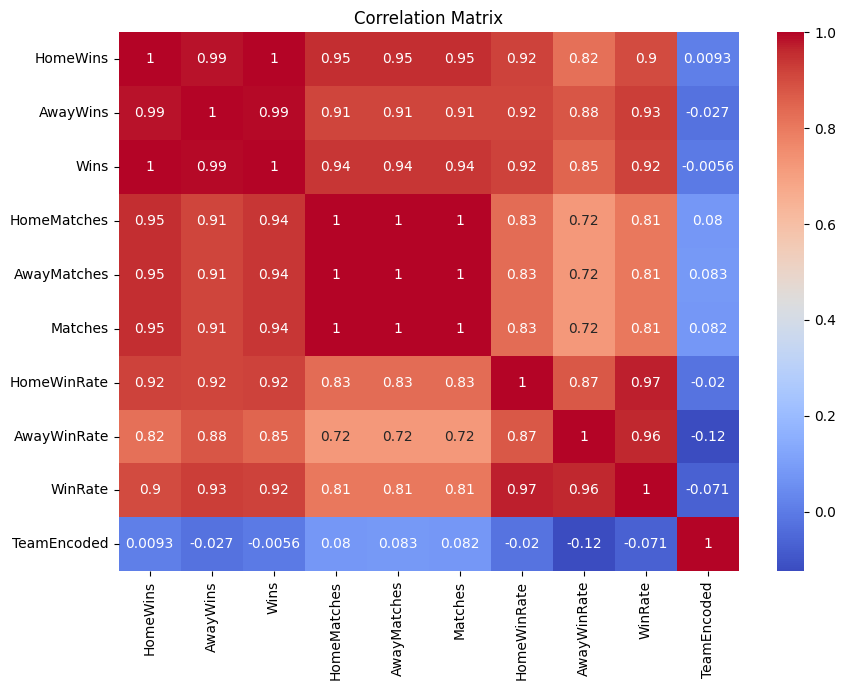


Columns most correlated with WinRate:
 HomeWinRate    0.972556
AwayWinRate    0.962255
AwayWins       0.928185
Wins           0.916614
HomeWins       0.902850
HomeMatches    0.806242
Matches        0.805833
AwayMatches    0.805234
TeamEncoded   -0.070806
Name: WinRate, dtype: float64

Columns most correlated with HomeWinRate:
 WinRate        0.972556
Wins           0.919841
HomeWins       0.917350
AwayWins       0.915301
AwayWinRate    0.872646
HomeMatches    0.831331
Matches        0.831052
AwayMatches    0.830578
TeamEncoded   -0.020194
Name: HomeWinRate, dtype: float64


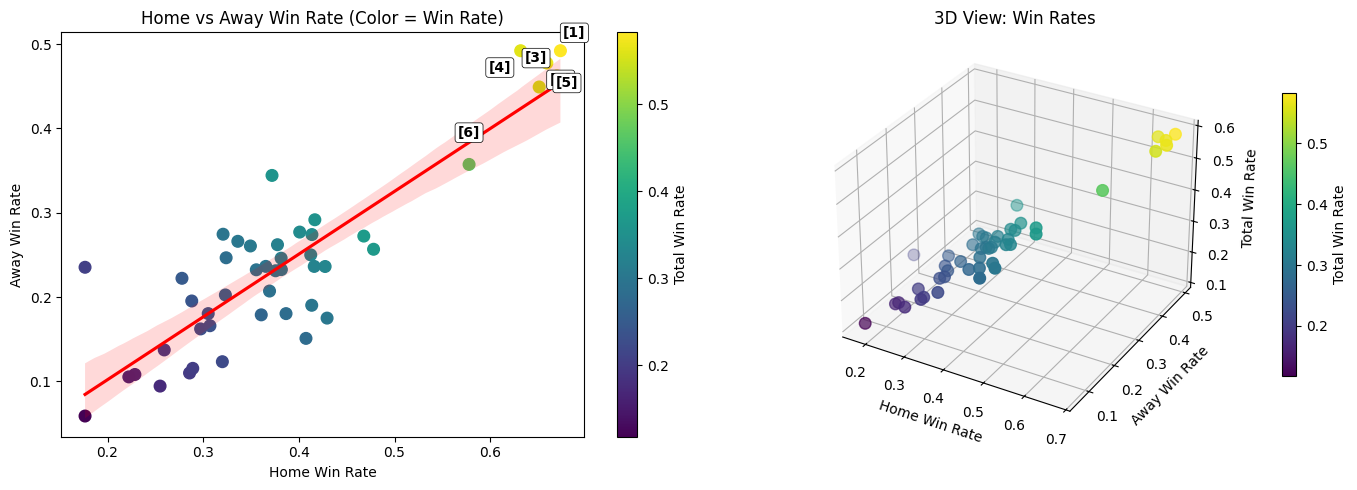

[1] = Man United
[2] = Liverpool
[3] = Arsenal
[4] = Chelsea
[5] = Man City
[6] = Tottenham


In [11]:
def compute_team_stats(df):
    home_wins = df[df['FullTimeResult'] == 'H'].groupby('HomeTeam').size()
    away_wins = df[df['FullTimeResult'] == 'A'].groupby('AwayTeam').size()
    
    home_matches = df.groupby('HomeTeam').size()
    away_matches = df.groupby('AwayTeam').size()
    
    teams = sorted(set(home_matches.index) | set(away_matches.index))
    stats = pd.DataFrame(index=teams)

    stats['HomeWins'] = home_wins
    stats['AwayWins'] = away_wins
    stats['Wins'] = home_wins.add(away_wins, fill_value=0)

    stats['HomeMatches'] = home_matches
    stats['AwayMatches'] = away_matches
    stats['Matches'] = home_matches.add(away_matches, fill_value=0)

    stats['HomeWinRate'] = stats['HomeWins'] / stats['HomeMatches']
    stats['AwayWinRate'] = stats['AwayWins'] / stats['AwayMatches']
    stats['WinRate'] = stats['Wins'] / stats['Matches']

    return stats.fillna(0)


# Plot heatmap of correlations
def plot_correlation_heatmap(df):
    plt.figure(figsize=(10, 7))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
    plt.title('Correlation Matrix')
    plt.show()


# Print correlations with specific columns
def print_correlations(df, column):
    corr = df.corr(numeric_only=True)[column].drop(column).sort_values(ascending=False)
    print(f"\nColumns most correlated with {column}:\n", corr)


# Visualize win rates in 2D and 3D
def plot_winrate_scatter(df):
    top6 = df.sort_values('WinRate', ascending=False).head(6)
    offsets = [(10,10), (10,-15), (-15,10), (-15,-15), (20,0), (0,20)]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sc = plt.scatter(df['HomeWinRate'], df['AwayWinRate'], c=df['WinRate'], cmap='viridis', s=70)
    sns.regplot(x='HomeWinRate', y='AwayWinRate', data=df, scatter=False, line_kws={'color': 'red'})
    plt.colorbar(sc, label='Total Win Rate')
    plt.title('Home vs Away Win Rate (Color = Win Rate)')
    plt.xlabel('Home Win Rate')
    plt.ylabel('Away Win Rate')

    for i, (idx, row) in enumerate(top6.iterrows(), 1):
        plt.annotate(
            f"[{i}]",
            (row['HomeWinRate'], row['AwayWinRate']),
            textcoords="offset points",
            xytext=offsets[i-1],
            ha='center',
            fontsize=10,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.5)
        )

    ax = plt.subplot(1, 2, 2, projection='3d')
    p = ax.scatter(df['HomeWinRate'], df['AwayWinRate'], df['WinRate'], c=df['WinRate'], cmap='viridis', s=70)
    ax.set_xlabel('Home Win Rate')
    ax.set_ylabel('Away Win Rate')
    ax.set_zlabel('Total Win Rate')
    plt.title('3D View: Win Rates')
    plt.colorbar(p, ax=ax, shrink=0.7, pad=0.1, label='Total Win Rate')

    plt.tight_layout()
    plt.show()

    for i, idx in enumerate(top6.index, 1):
        print(f"[{i}] = {idx}")


stats = compute_team_stats(cleaned_df)
stats_clean = stats.copy()

le = LabelEncoder()
stats_clean['TeamEncoded'] = le.fit_transform(stats_clean.index)

plot_correlation_heatmap(stats_clean)
print_correlations(stats_clean, 'WinRate')
print_correlations(stats_clean, 'HomeWinRate')

plot_winrate_scatter(stats_clean)

### What are the Key Performance Indicators (KPIs) for the football teams? What can we learn from those?

Let's take a comprehensive study on the key performance metrics of the teams across the years and compare data.

### Key Performance Indicators (KPIs) Derived

- **Goals Scored & Conceded:** Measures attacking and defensive strength.
- **Shots & Shots on Target:** Indicates attacking volume and quality.
- **Finishing Efficiency:** Ratio of goals scored to shots on target, showing how clinical a team is.
- **Shot Accuracy:** Ratio of shots on target to total shots, reflecting shooting precision.
- **Corners, Fouls, Yellow/Red Cards:** Proxy for attacking pressure and discipline.
- **Points & League Position:** Overall success and ranking.
- **Match Competitiveness & Excitement Index:** Quantifies match intensity and entertainment value.
- **Expected Goals (xG):** Estimates underlying performance based on shot quality.

### What can we derive from those?

- **Team Efficiency:** By comparing finishing efficiency and shot accuracy, we can identify the most clinical and precise teams each season.
- **Consistency vs. Success:** Analyzing variance in match results and points helps reveal if consistent teams are more likely to succeed.
- **Home Advantage Trends:** Functions analyze how home win rates have changed over time, especially before and after 2020.
- **Predictive Modeling:** Using match statistics, we can build models to predict match outcomes and identify which features are most predictive.
- **Seasonal & Temporal Trends:** Aggregating KPIs by season allows us to track changes in team performance, competitiveness, and league balance over time.

The upcoming functions in this notebook automate the calculation, ranking, and visualization of these KPIs, enabling deep dives into team performance, efficiency, and broader league trends.

Worked by: Matias Mirdita

In [12]:
def process_home_stats(df):
    home_stats = df[['Season', 'HomeTeam', 'FullTimeHomeGoals', 'FullTimeAwayGoals',
                     'HomeShotsOnTarget', 'HomeShots', 'HomeCorners',
                     'HomeFouls', 'HomeYellowCards', 'HomeRedCards', 'FullTimeResult']].copy()

    home_stats = home_stats.rename(columns={
        'HomeTeam': 'Team',
        'FullTimeHomeGoals': 'GoalsScored',
        'FullTimeAwayGoals': 'GoalsConceded',
        'HomeShotsOnTarget': 'ShotsOnTarget',
        'HomeShots': 'Shots',
        'HomeCorners': 'Corners',
        'HomeFouls': 'Fouls',
        'HomeYellowCards': 'YellowCards',
        'HomeRedCards': 'RedCards'
    })

    home_stats['Points'] = home_stats['FullTimeResult'].map({'H': 3, 'D': 1, 'A': 0})
    return home_stats

def process_away_stats(df):
    away_stats = df[['Season', 'AwayTeam', 'FullTimeAwayGoals', 'FullTimeHomeGoals',
                     'AwayShotsOnTarget', 'AwayShots', 'AwayCorners',
                     'AwayFouls', 'AwayYellowCards', 'AwayRedCards', 'FullTimeResult']].copy()

    away_stats = away_stats.rename(columns={
        'AwayTeam': 'Team',
        'FullTimeAwayGoals': 'GoalsScored',
        'FullTimeHomeGoals': 'GoalsConceded',
        'AwayShotsOnTarget': 'ShotsOnTarget',
        'AwayShots': 'Shots',
        'AwayCorners': 'Corners',
        'AwayFouls': 'Fouls',
        'AwayYellowCards': 'YellowCards',
        'AwayRedCards': 'RedCards'
    })

    away_stats['Points'] = away_stats['FullTimeResult'].map({'A': 3, 'D': 1, 'H': 0})
    return away_stats

def enforce_integer_columns(df, columns):
    for col in columns:
        df[col] = df[col].astype(int)
    return df

def aggregate_team_season_stats(all_stats, int_cols):
    team_season = all_stats.groupby(['Season', 'Team']).agg({
        'GoalsScored': 'sum',
        'GoalsConceded': 'sum',
        'ShotsOnTarget': 'sum',
        'Shots': 'sum',
        'Corners': 'sum',
        'Fouls': 'sum',
        'YellowCards': 'sum',
        'RedCards': 'sum',
        'Points': 'sum'
    }).reset_index()

    team_season = enforce_integer_columns(team_season, int_cols)

    team_season['Position'] = team_season.groupby('Season')['Points'] \
                                         .rank(ascending=False, method='first') \
                                         .astype(int)
    return team_season

def generate_team_season_kpis_no_possession(df):
    int_cols = ['GoalsScored', 'GoalsConceded', 'ShotsOnTarget', 'Shots', 'Corners',
                'Fouls', 'YellowCards', 'RedCards', 'Points']

    home_stats = enforce_integer_columns(process_home_stats(df), int_cols)
    away_stats = enforce_integer_columns(process_away_stats(df), int_cols)

    all_stats = pd.concat([home_stats, away_stats], axis=0)
    team_season_kpis = aggregate_team_season_stats(all_stats, int_cols)

    return team_season_kpis

kpis_df = generate_team_season_kpis_no_possession(cleaned_df)

### Match Distribution by Weekday
Understanding the distribution of English Premier League (EPL) matches across weekdays provides critical context for interpreting team performance trends, broadcast strategies, and logistical planning.


- Viewer Engagement & Revenue: Weekend fixtures (Saturday and Sunday) traditionally draw higher attendance and television viewership, which influences scheduling decisions, sponsorship exposure, and ticket sales.

- Squad Rotation Strategy: Matches scheduled midweek (especially Wednesdays and Thursdays) often suggest tighter fixture congestion, forcing teams to rotate lineups or manage player fatigue — an important consideration in performance-related KPI analysis.

- Post-COVID Era Shifts: After 2020, rescheduling due to pandemic constraints altered traditional matchday patterns. This graph helps identify these shifts and their long-term impact on league operations.

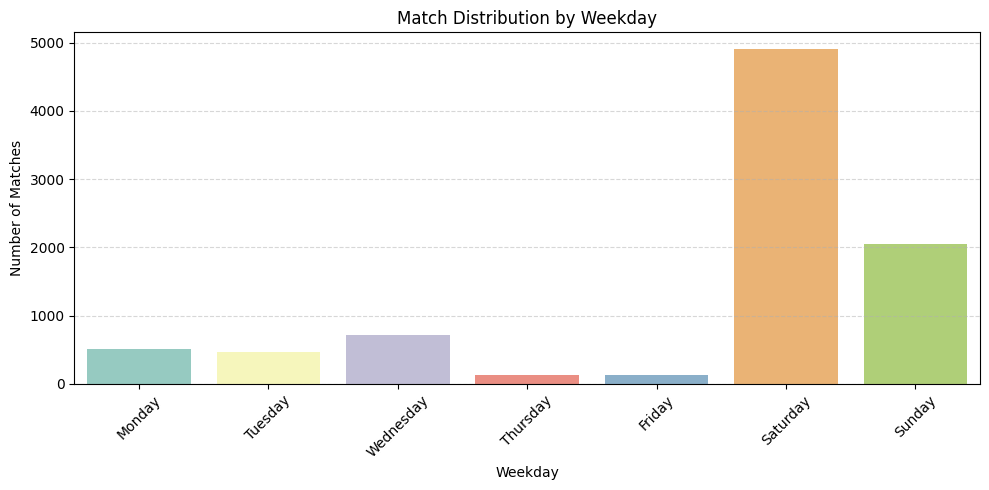

In [13]:
def plot_match_distribution_by_weekday(df):
    """
    Plots the number of matches played on each day of the week.
    """
    if 'Weekday' not in df.columns:
        print("Missing 'Weekday' column in DataFrame.")
        return

    plt.figure(figsize=(10, 5))
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.countplot(x='Weekday', data=df, order=order, palette='Set3')
    plt.title("Match Distribution by Weekday")
    plt.xlabel("Weekday")
    plt.ylabel("Number of Matches")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_match_distribution_by_weekday(cleaned_df)

### Total Goals per Season: Trend Analysis

Tracking the total number of goals scored across each English Premier League season reveals deeper patterns in attacking trends, rule impacts, and team tactics.

**Why this matters:**
- Tactical Evolution: A rise in goals may indicate offensive-oriented strategies (e.g., high pressing, wide play), while a drop may suggest defensive compactness or balance-focused gameplay.

- Rule & Technology Influence: The introduction of goal-line technology (2013), VAR (2019), and handball rule changes influence scoring consistency and frequency.

- Team Composition & Strategy: Seasons with unusually high or low scoring could be influenced by dominant offensive teams or increased parity in the league.

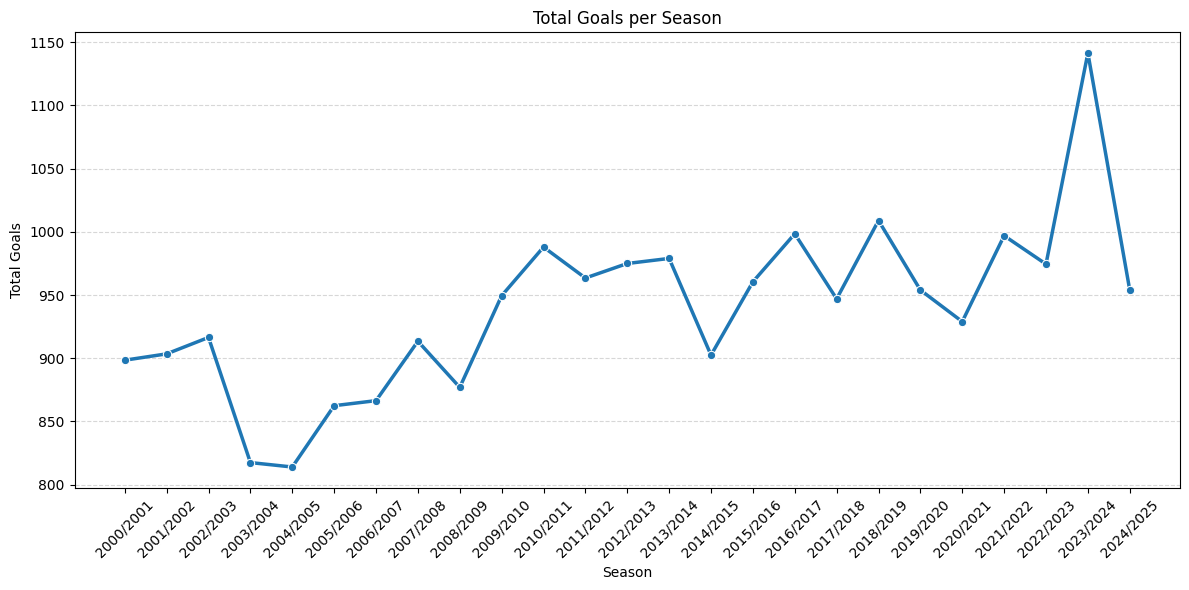

In [14]:
def plot_total_goals_per_season(df):
    """
    Plots the total number of goals scored per season (home + away).
    """
    required_cols = ['Season', 'FullTimeHomeGoals', 'FullTimeAwayGoals']
    if not all(col in df.columns for col in required_cols):
        print("Missing one or more required columns in DataFrame.")
        return

    goals_per_season = (
        df.groupby('Season')[['FullTimeHomeGoals', 'FullTimeAwayGoals']]
          .sum()
          .assign(TotalGoals=lambda x: x['FullTimeHomeGoals'] + x['FullTimeAwayGoals'])
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=goals_per_season,
        x=goals_per_season.index,
        y='TotalGoals',
        marker='o',
        linewidth=2.5
    )
    plt.title('Total Goals per Season')
    plt.xlabel('Season')
    plt.ylabel('Total Goals')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_total_goals_per_season(cleaned_df)

### Match Outcome Distribution in the EPL

Understanding how often matches result in a home win (H), draw (D), or away win (A) forms the foundational layer for any outcome-based analysis or predictive modeling in sports analytics.

**Why this matters:**

- Baseline for Predictive Models: Before applying machine learning to predict match results, it's critical to observe whether the dataset is balanced or skewed (e.g., are home wins disproportionately frequent?).

- Home Advantage Evidence: A dominant number of home wins may point to persistent home advantage, a known phenomenon in football influenced by crowd support, pitch familiarity, and travel fatigue.

- Strategy and Variance: If away wins or draws are underrepresented, tactical adjustments in away fixtures or late-game decisions might be contributing factors.

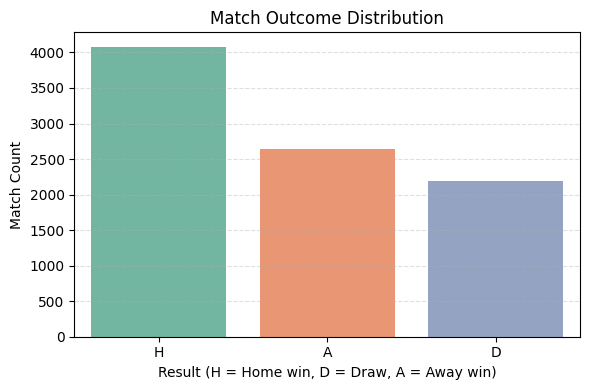

In [15]:
def plot_match_result_distribution(df):
    """
    Plots the distribution of match outcomes (Home win, Draw, Away win).
    """
    if 'Result' not in df.columns:
        print("Column 'Result' not found in DataFrame.")
        return

    plt.figure(figsize=(6, 4))
    sns.countplot(
        x='Result',
        data=df,
        palette='Set2'
    )
    plt.title('Match Outcome Distribution')
    plt.xlabel('Result (H = Home win, D = Draw, A = Away win)')
    plt.ylabel('Match Count')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

plot_match_result_distribution(cleaned_df)

## <span style="color:olive">Problem Statement 1</span>
### Can match KPIs and statistics accurately predict the full-time outcome of an EPL match?
Objective: Build a classification model (Random Forest) to predict whether a match will end in a Home Win, Draw, or Away Win using features like shots, fouls, and cards.

Why it matters: Can be used for betting, team strategy, or fan analytics.

How to measure: Accuracy, F1-score, feature importance.

Worked by: Albina Peposhi

### Seasonal Analysis of Team Efficiency and Shot Performance

To initiate our investigation into performance trends over time, we conduct a season-wise analysis of team-level finishing efficiency. This allows us to identify which teams consistently convert their attacking opportunities into goals with high efficiency.

Finishing efficiency is defined as the ratio of goals scored to shots on target. For each season, we extract the top 3 performing teams based on this metric and visualize their finishing efficiency and volume of shots on target using grouped bar charts.

This comparative analysis serves two main purposes:
- It highlights **efficiency leaders** across multiple seasons.
- It uncovers trends and trade-offs between **shot volume** and **conversion quality**.

By focusing on these seasonal KPIs, we begin to uncover strategic patterns and identify high-performing clubs in terms of offensive execution.

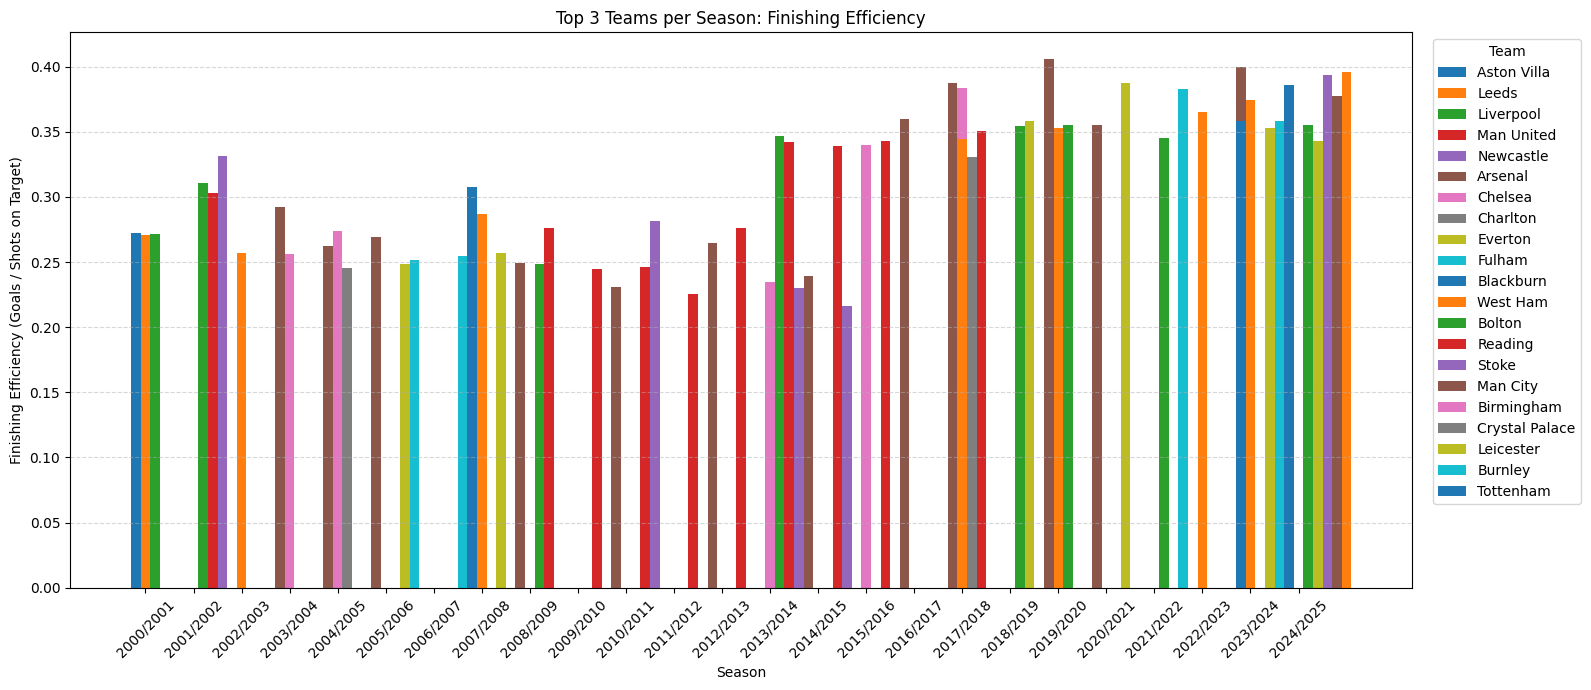

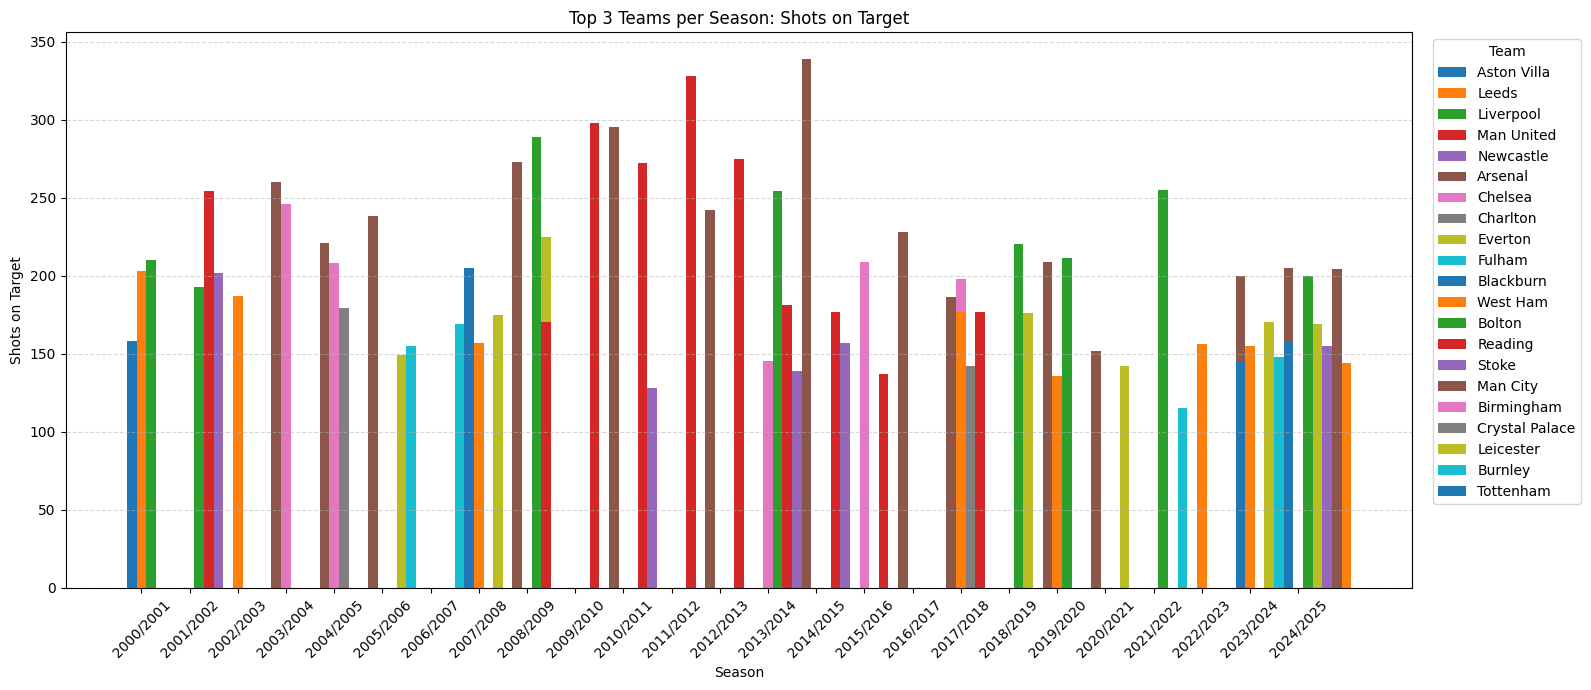

Top 3 teams by finishing efficiency for each season:


,Season,Team,GoalsScored,ShotsOnTarget,FinishingEfficiency,EfficiencyRank
1,2000/2001,Aston Villa,43,158,0.272152,1.0
11,2000/2001,Liverpool,57,210,0.271429,2.0
9,2000/2001,Leeds,55,203,0.270936,3.0
35,2001/2002,Newcastle,67,202,0.331683,1.0
32,2001/2002,Liverpool,60,193,0.310881,2.0
...,...,...,...,...,...,...
461,2023/2024,Aston Villa,65,174,0.373563,2.0
460,2023/2024,Arsenal,73,205,0.356098,3.0
494,2024/2025,Newcastle,61,155,0.393548,1.0
480,2024/2025,Arsenal,61,165,0.369697,2.0


In [16]:
def compute_finishing_efficiency(df):
    """
    Adds finishing efficiency (Goals / Shots on Target) to the dataframe.
    Handles divisions by zero and drops invalid entries.
    """
    df = df.copy()
    df['FinishingEfficiency'] = df['GoalsScored'] / df['ShotsOnTarget']
    df['FinishingEfficiency'] = df['FinishingEfficiency'].replace([np.inf, -np.inf], np.nan)
    return df.dropna(subset=['FinishingEfficiency', 'ShotsOnTarget'])

def get_top3_teams_per_season(df):
    """
    Assigns efficiency rank per season and filters top 3 teams per season.
    """
    df['EfficiencyRank'] = df.groupby('Season')['FinishingEfficiency'] \
                             .rank(ascending=False, method='first')
    return df[df['EfficiencyRank'] <= 3].copy()

def get_team_colors(teams):
    """
    Returns a dictionary mapping team names to unique colors.
    """
    palette = sns.color_palette('tab10', n_colors=len(teams))
    return dict(zip(teams, palette))

def plot_grouped_bar(df, metric, title, ylabel, team_colors):
    """
    Generic grouped bar plot function for the given metric (e.g., FinishingEfficiency, ShotsOnTarget).
    """
    seasons = sorted(df['Season'].unique())
    teams = df['Team'].unique()
    bar_width = 0.2

    plt.figure(figsize=(16, 7))
    for i, team in enumerate(teams):
        team_data = df[df['Team'] == team].set_index('Season').reindex(seasons)
        x = np.arange(len(seasons)) + i * bar_width
        plt.bar(x, team_data[metric], width=bar_width, label=team, color=team_colors[team])
    
    plt.xticks(np.arange(len(seasons)) + bar_width, seasons, rotation=45)
    plt.title(title)
    plt.xlabel("Season")
    plt.ylabel(ylabel)
    plt.legend(title="Team", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_top3_efficiency_and_shots_over_seasons(team_season_kpis):
    """
    Main function to compute and plot:
    1. Finishing Efficiency for top 3 teams each season.
    2. Shots on Target for those same teams.
    """
    df_eff = compute_finishing_efficiency(team_season_kpis)
    top3 = get_top3_teams_per_season(df_eff)
    team_colors = get_team_colors(top3['Team'].unique())

    plot_grouped_bar(top3, 'FinishingEfficiency', 
                     'Top 3 Teams per Season: Finishing Efficiency',
                     'Finishing Efficiency (Goals / Shots on Target)',
                     team_colors)
    
    plot_grouped_bar(top3, 'ShotsOnTarget', 
                     'Top 3 Teams per Season: Shots on Target',
                     'Shots on Target',
                     team_colors)

    print("Top 3 teams by finishing efficiency for each season:")
    display(top3[['Season', 'Team', 'GoalsScored', 'ShotsOnTarget', 'FinishingEfficiency', 'EfficiencyRank']] \
            .sort_values(['Season', 'EfficiencyRank']))

plot_top3_efficiency_and_shots_over_seasons(kpis_df)

### Analyzing Home Advantage: Pre vs Post 2020

To understand whether the traditional home-field advantage in the English Premier League has shifted over time, especially around the 2020 mark (notably impacted by the COVID-19 pandemic), we conduct a three-part analysis:

1. **Home vs Away Win Rate**: Compares the proportion of wins for home and away teams before and after 2020.
2. **Average Goals Scored**: Looks at whether home teams are scoring more (or less) compared to away teams across both time periods.
3. **Average Shots on Target**: Analyzes attacking output, regardless of goal conversion.

Together, these KPIs help uncover whether the psychological or tactical benefits of playing at home have diminished in recent years

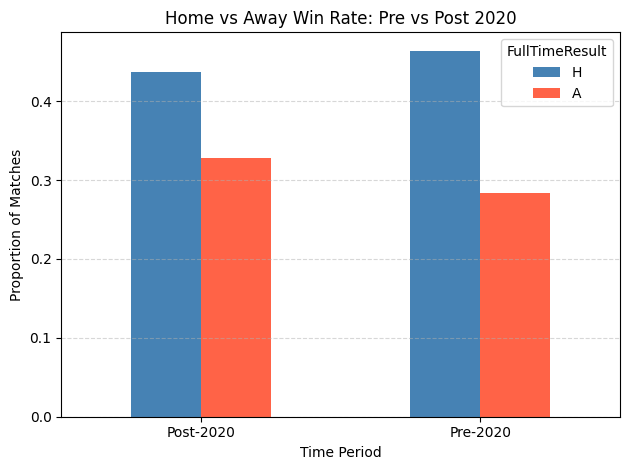

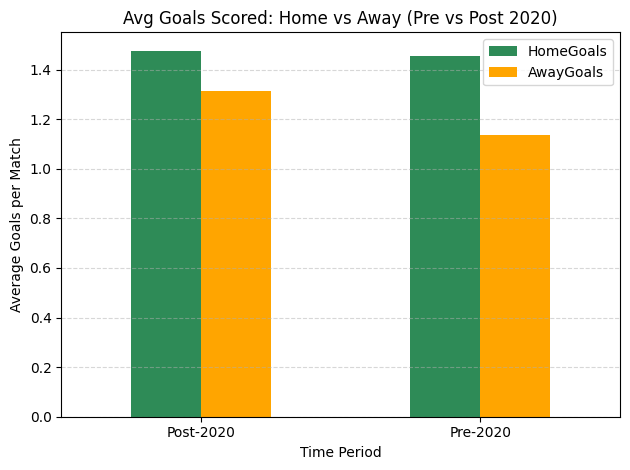

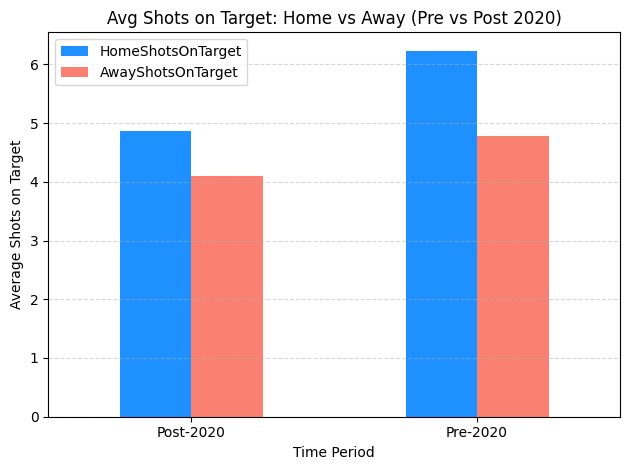

In [17]:
def add_decade_column(df):
    """Add 'Year' and 'Decade' columns based on MatchDate."""
    df = df.copy()
    df['Year'] = df['MatchDate'].dt.year
    df['Decade'] = np.where(df['Year'] < 2020, 'Pre-2020', 'Post-2020')
    return df

def plot_win_rate_by_decade(df):
    """Plot proportion of Home vs Away wins for Pre vs Post 2020."""
    win_rate = df.groupby(['Decade', 'FullTimeResult']).size().unstack().fillna(0)
    win_rate_pct = win_rate.div(win_rate.sum(axis=1), axis=0)
    
    win_rate_pct[['H', 'A']].plot(kind='bar', stacked=False, color=['steelblue', 'tomato'])
    plt.title("Home vs Away Win Rate: Pre vs Post 2020")
    plt.ylabel("Proportion of Matches")
    plt.xlabel("Time Period")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_avg_goals_by_decade(df):
    """Plot average goals scored by home and away teams before and after 2020."""
    avg_goals = df.groupby('Decade')[['FullTimeHomeGoals', 'FullTimeAwayGoals']].mean()
    avg_goals.rename(columns={'FullTimeHomeGoals': 'HomeGoals', 'FullTimeAwayGoals': 'AwayGoals'}, inplace=True)
    
    avg_goals.plot(kind='bar', color=['seagreen', 'orange'])
    plt.title("Avg Goals Scored: Home vs Away (Pre vs Post 2020)")
    plt.ylabel("Average Goals per Match")
    plt.xlabel("Time Period")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_avg_shots_by_decade(df):
    """Plot average shots on target by home and away teams before and after 2020."""
    avg_shots = df.groupby('Decade')[['HomeShotsOnTarget', 'AwayShotsOnTarget']].mean()
    avg_shots.rename(columns={'HomeShotsOnTarget': 'HomeShotsOnTarget', 'AwayShotsOnTarget': 'AwayShotsOnTarget'}, inplace=True)
    
    avg_shots.plot(kind='bar', color=['dodgerblue', 'salmon'])
    plt.title("Avg Shots on Target: Home vs Away (Pre vs Post 2020)")
    plt.ylabel("Average Shots on Target")
    plt.xlabel("Time Period")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def analyze_home_advantage_extended(df):
    """
    Perform a modular analysis of home advantage:
    1. Win rates pre/post 2020
    2. Average goals scored
    3. Average shots on target
    """
    df = add_decade_column(df)
    
    plot_win_rate_by_decade(df)
    plot_avg_goals_by_decade(df)
    plot_avg_shots_by_decade(df)

analyze_home_advantage_extended(cleaned_df)

### Team Consistency vs League Success

In this section, we explore whether **consistency in earning points** throughout a season contributes to **final league success** — supporting our broader question:

> **Can match KPIs and statistics accurately predict the full-time outcome of an EPL match?**

#### What We Measure
- For each team, we calculate the **standard deviation (std)** of match points earned (3 for a win, 1 for a draw, 0 for a loss).
- We then compare this to the **final league position** (1 = best, 20 = worst).
- A lower standard deviation indicates a more **consistent** team performance across the season.

#### Why It Matters
In football, teams that avoid "bad days" and maintain steady performance are more likely to finish higher. This analysis helps answer:
- Is consistency more predictive of success than peak performance?
- Can point variance act as a feature in predictive models?

#### What We Visualized here
- A **scatter plot** showing the relationship between a team’s standard deviation in points and their final league ranking.
- Lists of the **most and least consistent teams**, alongside their season performance.

This analysis supports the idea that **consistency is a predictive KPI** and could be used in future match outcome models or season simulations.

Investigating the value of consistency across matches...

Correlation between points std and league position: -0.274 (lower position = better rank)

🟢 Most Consistent Teams:


,Season,Team,std,Position,Points
146,2007/2008,Derby,0.614636,20,10
496,2024/2025,Southampton,0.787375,20,11
389,2019/2020,Liverpool,0.825029,1,95
476,2023/2024,Sheffield United,0.867325,20,16
369,2018/2019,Huddersfield,0.874234,20,15



🔴 Least Consistent Teams:


,Season,Team,std,Position,Points
376,2018/2019,Tottenham,1.443636,5,68
408,2020/2021,Leeds,1.440705,10,55
271,2013/2014,Newcastle,1.434768,9,49
420,2021/2022,Arsenal,1.424279,5,66
113,2005/2006,Newcastle,1.421917,7,53


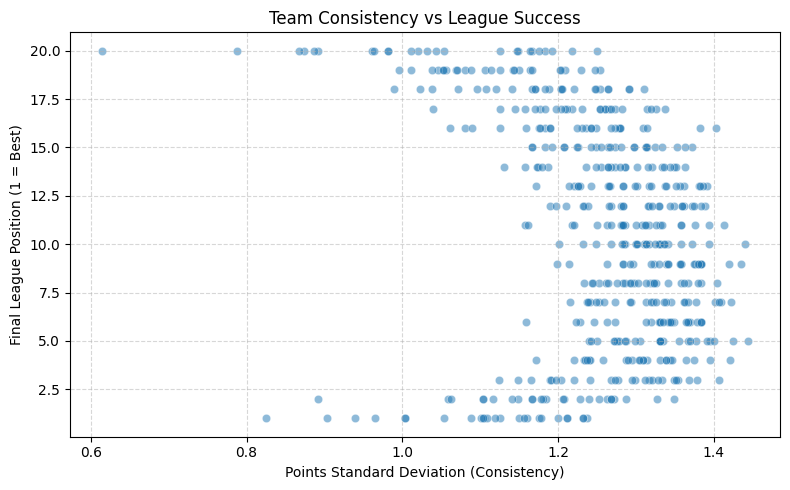

In [18]:
def compute_match_point_stats(df_home_away):
    """
    Combine home and away points per team and compute season-level point std deviation.
    """
    home = df_home_away[['Season', 'HomeTeam', 'HomePoints']].rename(
        columns={'HomeTeam': 'Team', 'HomePoints': 'Points'})
    away = df_home_away[['Season', 'AwayTeam', 'AwayPoints']].rename(
        columns={'AwayTeam': 'Team', 'AwayPoints': 'Points'})
    
    combined = pd.concat([home, away], axis=0)

    stats = combined.groupby(['Season', 'Team'])['Points'] \
                    .agg(['mean', 'std', 'count']) \
                    .reset_index()
    return stats

def merge_with_league_position(stats_df, team_kpis_df):
    """
    Merge calculated point variance with final league rankings and points.
    """
    return pd.merge(stats_df, 
                    team_kpis_df[['Season', 'Team', 'Position', 'Points']],
                    on=['Season', 'Team'])

def plot_consistency_vs_position(merged_df):
    """
    Scatter plot showing relationship between consistency (std) and final position.
    """
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='std', y='Position', data=merged_df, alpha=0.5)
    plt.xlabel('Points Standard Deviation (Consistency)')
    plt.ylabel('Final League Position (1 = Best)')
    plt.title('Team Consistency vs League Success')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def display_extreme_consistency_cases(merged_df):
    """
    Print most consistent and least consistent teams with their ranking.
    """
    print("\n🟢 Most Consistent Teams:")
    display(merged_df.sort_values('std').head(5)[['Season', 'Team', 'std', 'Position', 'Points']])

    print("\n🔴 Least Consistent Teams:")
    display(merged_df.sort_values('std', ascending=False).head(5)[['Season', 'Team', 'std', 'Position', 'Points']])

def team_consistency_vs_success(df_matchpoints, team_kpis_df):
    """
    Main function to:
    - Calculate match point variance (std)
    - Correlate with final league position
    - Visualize and interpret consistency impact
    """
    print("Investigating the value of consistency across matches...")
    stats = compute_match_point_stats(df_matchpoints)
    merged = merge_with_league_position(stats, team_kpis_df)

    corr = merged['std'].corr(merged['Position'])
    print(f"\nCorrelation between points std and league position: {corr:.3f} (lower position = better rank)")

    display_extreme_consistency_cases(merged)
    plot_consistency_vs_position(merged)

    return merged

def add_match_points_columns(df):
    df = df.copy()
    df['HomePoints'] = df['FullTimeResult'].map({'H': 3, 'D': 1, 'A': 0})
    df['AwayPoints'] = df['FullTimeResult'].map({'A': 3, 'D': 1, 'H': 0})
    return df
cleaned_df_safe = add_match_points_columns(cleaned_df)

merged_consistency = team_consistency_vs_success(cleaned_df_safe, kpis_df)

### Head-to-Head Based Match Outcome Prediction

As an initial benchmark for our primary problem — **Can match KPIs and statistics accurately predict the full-time outcome of an EPL match?** — we implement a **historical head-to-head predictor** - to first be closer to the data itself.

#### What It Does
- Filters past matchups between two teams over the seasons.
- Aggregates historical outcomes (Home wins, Draws, Away wins).
- Calculates a simple empirical probability distribution based on these outcomes.
- Predicts the most likely outcome and visualizes the associated certainty.

#### Why This Matters
While not a machine learning model, this historical predictor:
- Acts as a **baseline** against which we can compare ML performance.
- Is easily interpretable and often useful in sports analytics (e.g. betting, commentary).
- Can be used to supplement ML-based models with prior-based features (e.g. head-to-head win rate).

#### Limitations
- It doesn’t generalize to new teams or account for evolving squad strength.
- Doesn't use in-match KPIs like shots, fouls, or player data.

In [19]:
# runs best in unix based systems
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

feature_cols = [
    'HomeShots', 'AwayShots',
    'HomeShotsOnTarget', 'AwayShotsOnTarget',
    'HomeFouls', 'AwayFouls',
    'HomeCorners', 'AwayCorners',
    'HomeYellowCards', 'AwayYellowCards'
]

model_df = cleaned_df.dropna(subset=feature_cols + ['FullTimeResult'])
X = model_df[feature_cols]
y = model_df['FullTimeResult'].map({'H': 0, 'D': 1, 'A': 2})
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

teams = sorted(cleaned_df['HomeTeam'].unique())
home_team = widgets.Dropdown(options=teams, description='Home Team:')
away_team = widgets.Dropdown(options=teams, description='Away Team:')
predict_btn = widgets.Button(description='Predict Outcome', button_style='success')
output = widgets.Output()

def predict_match_outcome_rf():
    with output:
        clear_output()

        if home_team.value == away_team.value:
            display(HTML("<b style='color:red'>Please select two different teams.</b>"))
            return

        # Use team medians as match proxy
        home_stats = cleaned_df[cleaned_df['HomeTeam'] == home_team.value][feature_cols[:5]].median()
        away_stats = cleaned_df[cleaned_df['AwayTeam'] == away_team.value][feature_cols[5:]].median()

        if home_stats.isnull().any() or away_stats.isnull().any():
            display(HTML("<b style='color:red'>Not enough data to predict.</b>"))
            return

        features = np.array([*home_stats.values, *away_stats.values]).reshape(1, -1)
        pred = rf_model.predict(features)[0]
        proba = rf_model.predict_proba(features)[0]

        labels = ['Home Win', 'Draw', 'Away Win']
        prediction = labels[pred]
        certainty = proba[pred]

        display(HTML(f"""
            <h4 style='color:#004d00'>Prediction: {prediction}</h4>
            <p><b>Certainty:</b> {certainty:.1%}</p>
        """))

        plt.figure(figsize=(6, 4))
        bars = plt.bar(['Home Win', 'Draw', 'Away Win'], proba, color=['#4CAF50', '#FFC107', '#2196F3'])
        for bar, prob in zip(bars, proba):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{prob:.0%}", ha='center', va='bottom')
        plt.title(f"Predicted Outcome Probabilities\n({home_team.value} vs {away_team.value})")
        plt.ylabel("Probability")
        plt.ylim(0, 1)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# Ensuring only one handler is active
predict_btn._click_handlers.callbacks.clear()
predict_btn.on_click(lambda b: predict_match_outcome_rf())

display(widgets.VBox([home_team, away_team, predict_btn, output]))

# <span style="color:olive">Problem statement 2</span>
## Which in-game metrics have the strongest influence on match outcomes?

*Objective:* Use correlation analysis and model coefficients to identify the most predictive match statistics (shots on target, fouls, yellow/red cards).

Why it matters: Helps coaches prioritize key metrics during training.

How to measure: Logistic regression coefficients, feature importance scores.

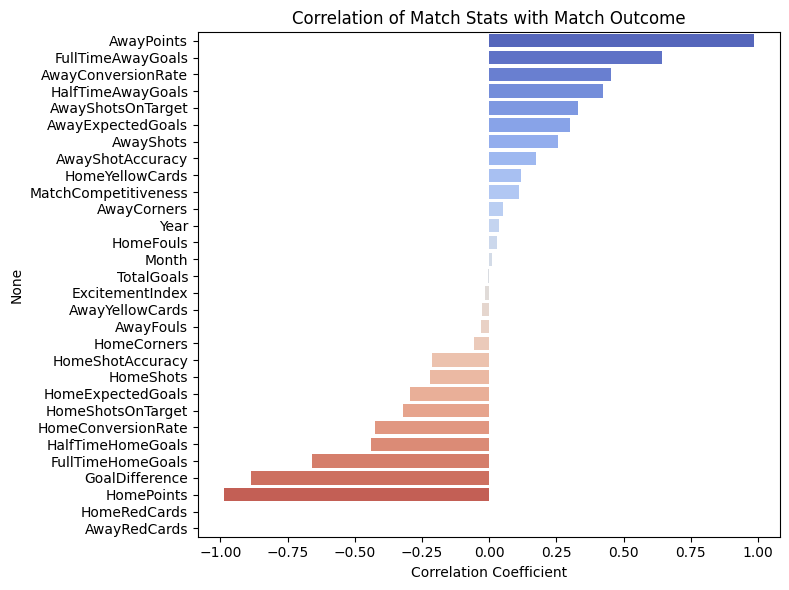

,MatchOutcome
AwayPoints,0.982798
FullTimeAwayGoals,0.643247
AwayConversionRate,0.451670
HalfTimeAwayGoals,0.424222
AwayShotsOnTarget,0.329930
AwayExpectedGoals,0.298650
AwayShots,0.256158
AwayShotAccuracy,0.175146
HomeYellowCards,0.117262
MatchCompetitiveness,0.112292


In [20]:
def encode_match_result(df):
    df = df.copy()
    if 'Result' not in df.columns:
        raise ValueError("Result column not found.")
    df['MatchOutcome'] = df['Result'].map({'H': 0, 'D': 1, 'A': 2})
    return df

def correlation_analysis(df, target_col='MatchOutcome'):
    """
    Shows correlation of numeric match stats with match outcome.
    """
    numeric_cols = df.select_dtypes(include='number').drop(columns=[target_col], errors='ignore')
    corr_df = df[[target_col] + list(numeric_cols.columns)].corr()[[target_col]].drop(index=target_col)
    corr_df = corr_df.sort_values(by=target_col, ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x=corr_df[target_col], y=corr_df.index, palette='coolwarm')
    plt.title("Correlation of Match Stats with Match Outcome")
    plt.xlabel("Correlation Coefficient")
    plt.tight_layout()
    plt.show()
    
    return corr_df

cleaned_df_safe = encode_match_result(cleaned_df_safe)
correlation_analysis(cleaned_df_safe)

### Feature Influence on Match Outcomes (Logistic Regression)

To understand which in-game metrics have the strongest influence on match outcomes (home win, draw, away win), we apply a **multinomial logistic regression** model. The model is trained using cleaned numeric KPIs such as shots, fouls, and cards, while the target is the full-time result of each match.

The resulting **model coefficients** indicate the relative influence of each KPI on the likelihood of different outcomes. Positive coefficients suggest a higher association with one class (e.g., home wins), while negative coefficients suggest the opposite effect.

This analysis helps identify which statistics most consistently predict match results — offering insights for **coaches, analysts, and automated decision systems** on where to focus training or tactical adjustments.

Model performance is further evaluated using standard metrics like **accuracy and F1-score** across a test split.

<Figure size 1000x700 with 0 Axes>

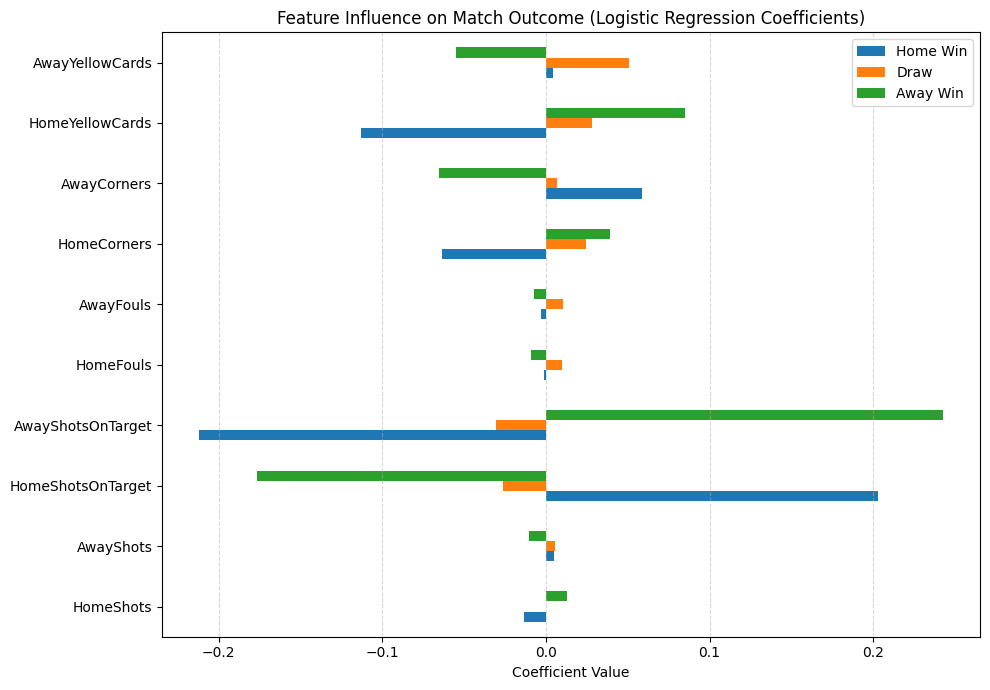

Model Performance on Test Data:

              precision    recall  f1-score   support

    Home Win       0.58      0.81      0.67       817
        Draw       0.35      0.04      0.08       442
    Away Win       0.54      0.60      0.57       524

    accuracy                           0.56      1783
   macro avg       0.49      0.49      0.44      1783
weighted avg       0.51      0.56      0.50      1783



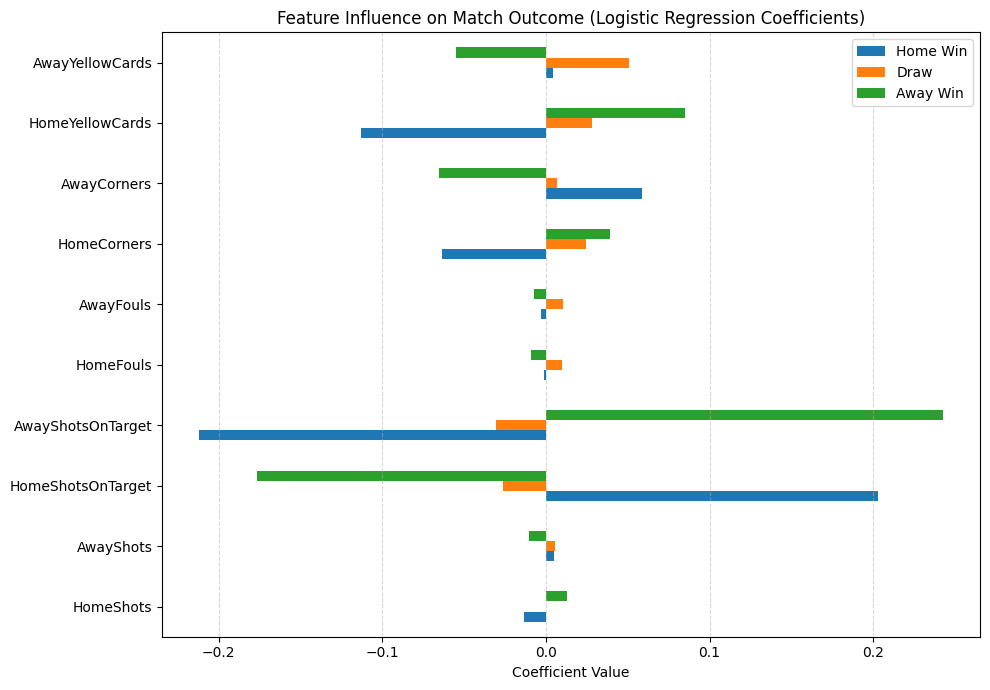

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def logistic_model_kpi_importance_fixed(X, y):
    """
    Trains a logistic regression model and shows coefficient importance of KPIs.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )
    model = LogisticRegression(max_iter=500, multi_class='multinomial')
    model.fit(X_train, y_train)
    coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=['Home Win', 'Draw', 'Away Win']).T

    plt.figure(figsize=(10, 7))
    coef_df.plot(kind='barh', figsize=(10, 7))
    plt.title('Feature Influence on Match Outcome (Logistic Regression Coefficients)')
    plt.xlabel('Coefficient Value')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("Model Performance on Test Data:\n")
    print(classification_report(y_test, model.predict(X_test), target_names=['Home Win', 'Draw', 'Away Win']))

    return coef_df

importance = logistic_model_kpi_importance_fixed(X, y)

def plot_kpi_importance(importance):
    """
    Plots the importance of KPIs based on logistic regression coefficients.
    """
    importance.plot(kind='barh', figsize=(10, 7))
    plt.title('Feature Influence on Match Outcome (Logistic Regression Coefficients)')
    plt.xlabel('Coefficient Value')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_kpi_importance(importance)